# Energy Sweeping

First we import some packages

In [1]:
import numpy as np
import pyPolygon as pp
from matplotlib import pyplot as plt

Then we make our packing. We want it to be a packing of N squares. We also make sure this demo is repeatable, so we set a random seed. We also make sure our box is slightly smaller than the theoretical smallest possible (side length = ????...)

The packing fraction is therefore N / sideLength^2. We can make the box a little smaller and use instead. This will help ensure we're overjammed.

FIRE (constrained):   0%|          | 0/100000 [00:00<?, ?it/s]

<Axes: >

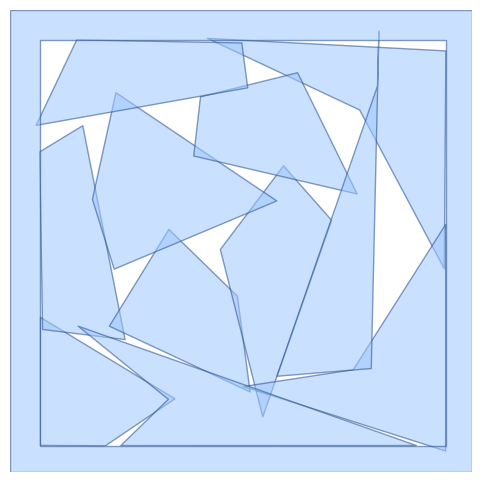

In [2]:
N = 11
sideLength = 3.5
packing = pp.Model(N = N, n = 4, seed = 40)
# The default if a seed isn't specified is to generate a random seed
packing.generateEquilateralPolygons(phi = N / (sideLength)**2, kappa = 4.0)
# We can synchronize the target perimeters and areas:
packing.syncTargetPerimeters()
packing.syncTargetAreas()
# Notice that phi is going to be too large so we'll get 
# overlapping squares no matter what.
packing.setLogNormalScale(polydispersity = 0.25)
# We want to also make the shapes polydisperse
packing.spreadShapes(polydispersity = 0.25)
# a target perimeter drawn from a log-normal distribution with std/mean of 0.1

# We then set our fixed boundary conditions
vertices = np.array([[0, 0], [0, 1], [1, 1], [1, 0]])
packing.addShape(vertices)
packing.pinVertices(np.arange(packing.getNumVertices())[-4:])
packing.setBoundaryConditions("fixed")
# We add some constraints:
packing.setConstraints(area = True, edge = False)
# And minimize
packing.minimizeFIRE(maxUnbalancedForce = 1e-2, progressBar = True)
packing.draw()

Next we let the areas and edgeLengths be degrees of freedom with a set of fixed moments of the distribution

In [3]:
# Now we minimize:
packing.setModelType("depth")
packing.setConstraints(area = [1, 2], distortion = [1, 2], edge = False)
packing.minimizeCG(maxUnbalancedForce = 1e-6, progressBar = True)

CG (constrained):   0%|          | 0/2000 [00:00<?, ?it/s]

(1.7978380979801837e-08, 17, True)

<Axes: >

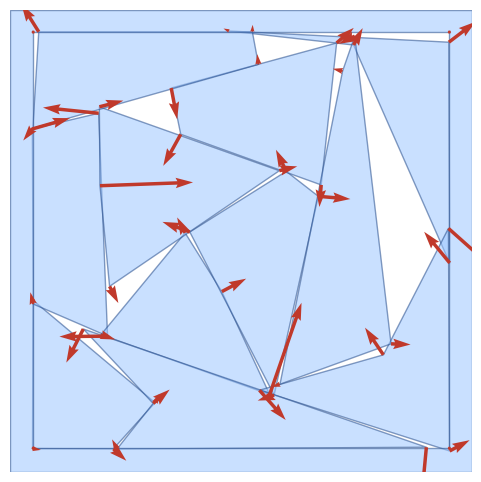

In [4]:
packing.draw(forces = packing.getForces())

## Next we create a schedule for reducing phi, polydispersity, and sigma

energySweep:   0%|          | 0/249 [00:00<?, ?it/s]

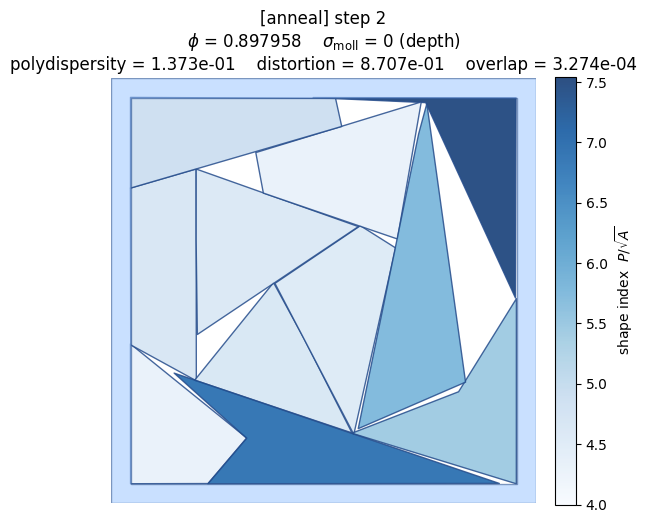

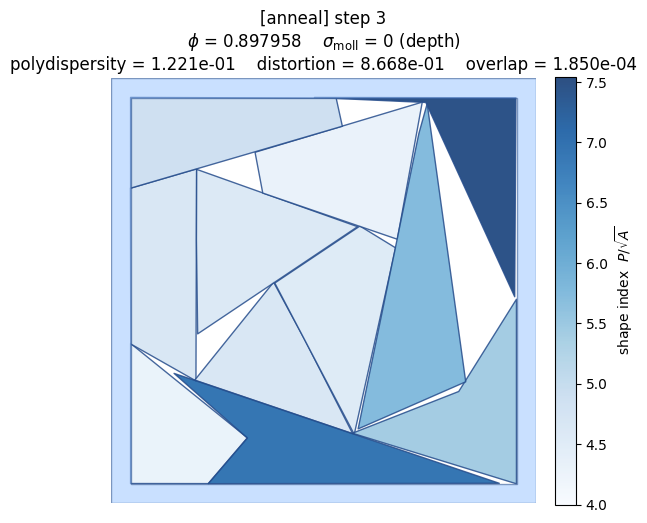

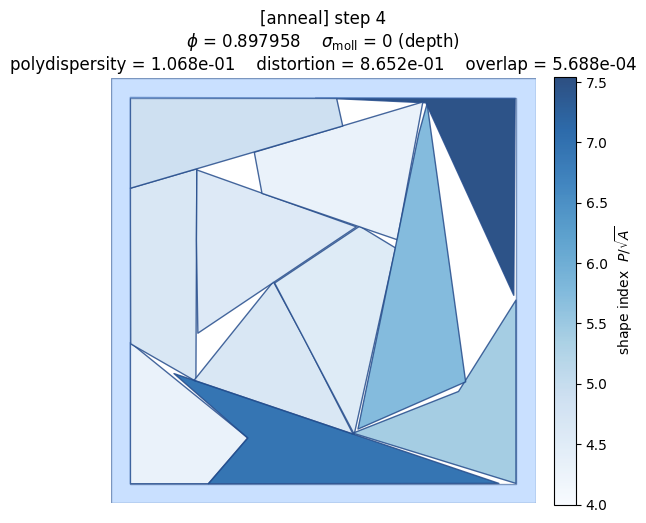

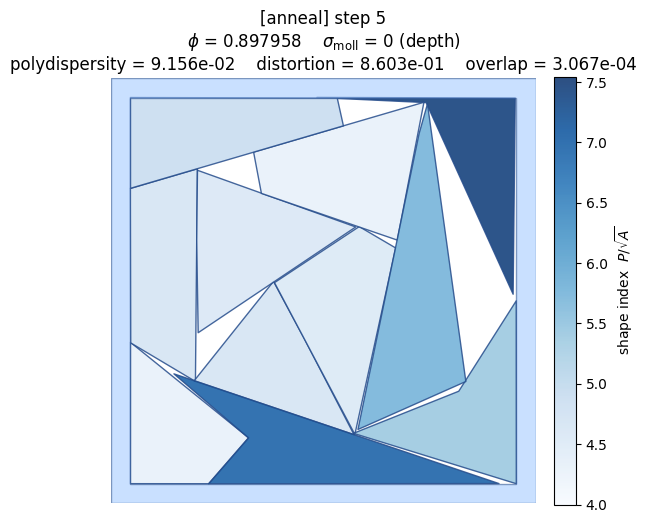

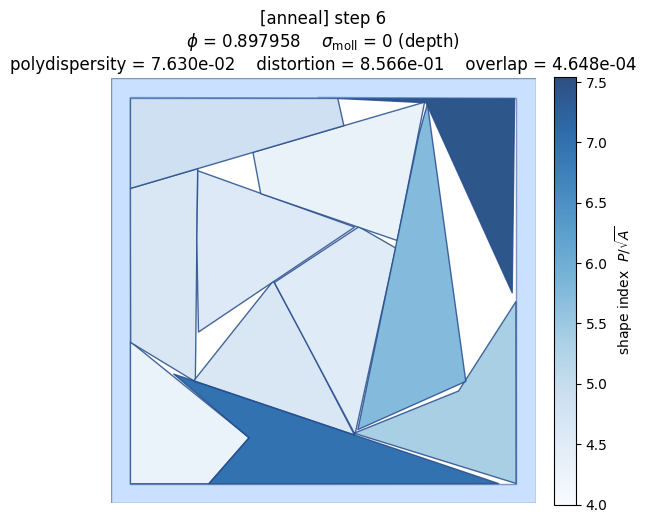

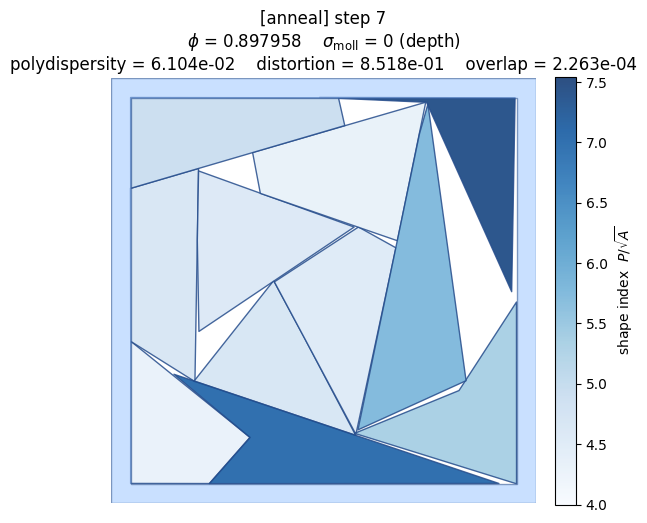

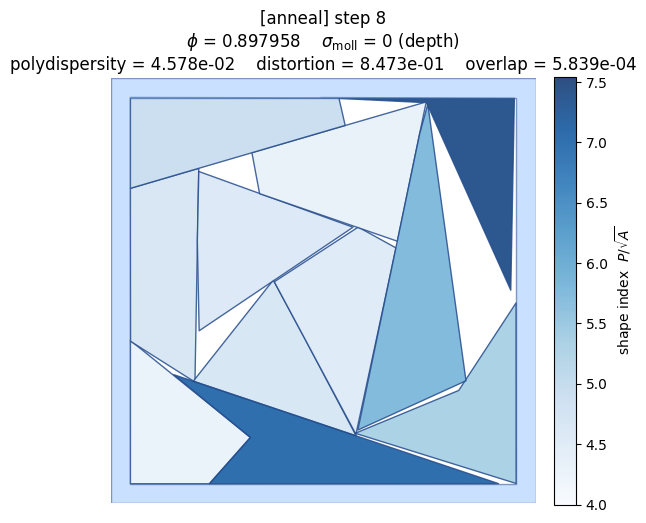

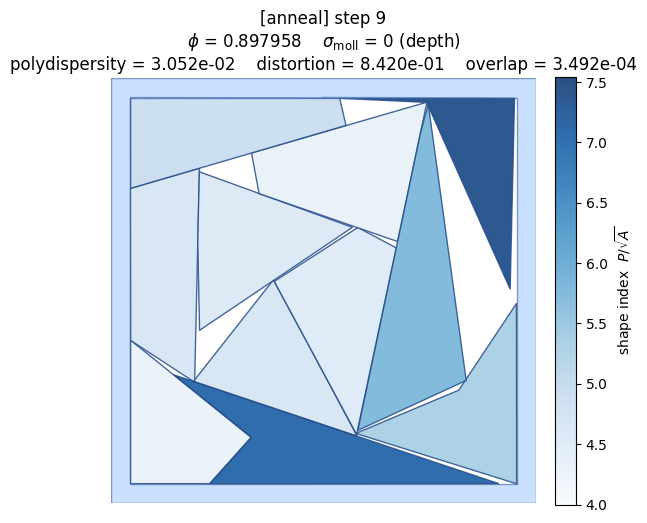

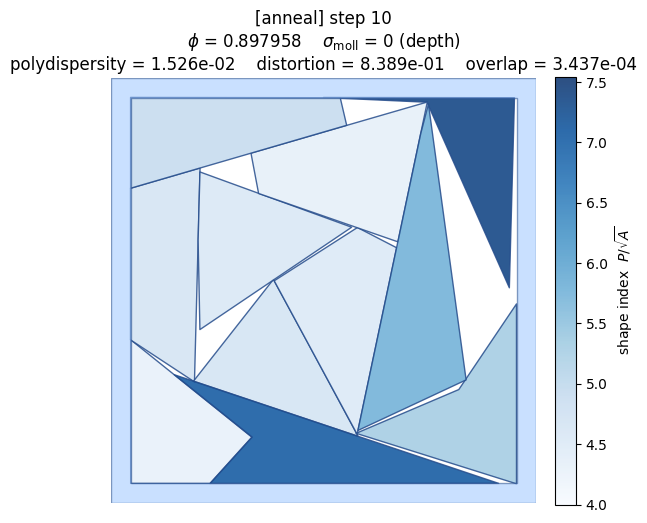

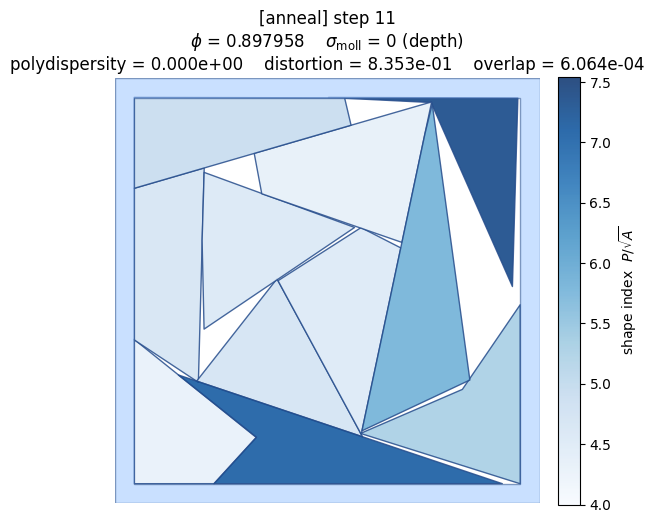

/home/rdennis/Documents/Code/pyPolygon/model.py:777: UserWarning: 
*** direct distortion constraint replaced by the deviation barrier ***
    setConstraints(distortion = [...]) holds the dimensionless d_i directly, but the shape anneal drives its target to zero and a DIRECT budget's gradient vanishes exactly there -- the ramp would stall short and hand off with a jump.
    The deviation form (shape = [1, -1]) is substituted for the sweep: its k = -1 row carries -delta^-2 and stiffens as the deficit shrinks, so the ramp can actually arrive. Pass energySweep(annealShape = False) to keep your own constraint set instead.
  return anneal.energySweep(
/home/rdennis/Documents/Code/pyPolygon/model.py:777: UserWarning: 
*** area moments replaced by per-object area constraints for the shape anneal ***
    the distortion ramp needs the deviation form, and 'deviation' applies to the whole constraint set, so area moments would become a shrink-only A0 - A barrier -- singular as soon as any polygon e

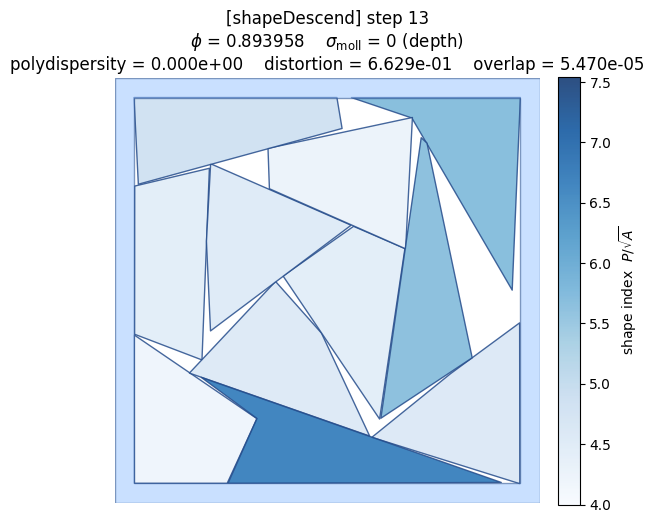

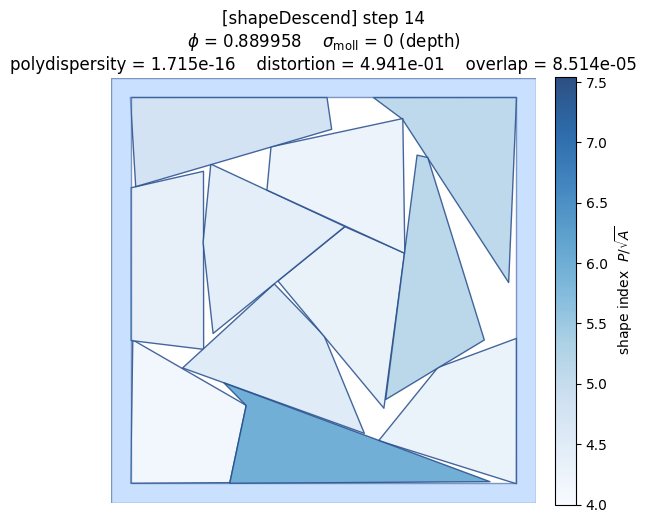

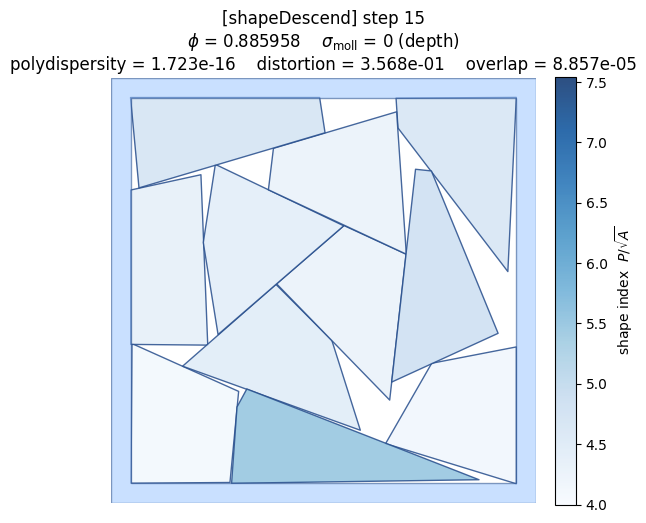

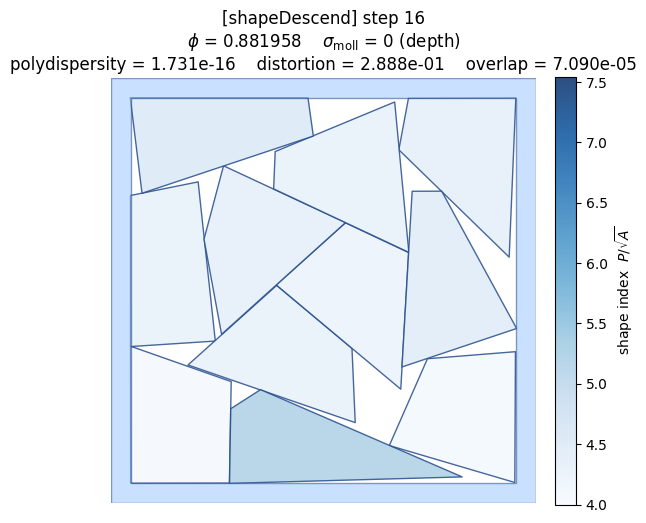

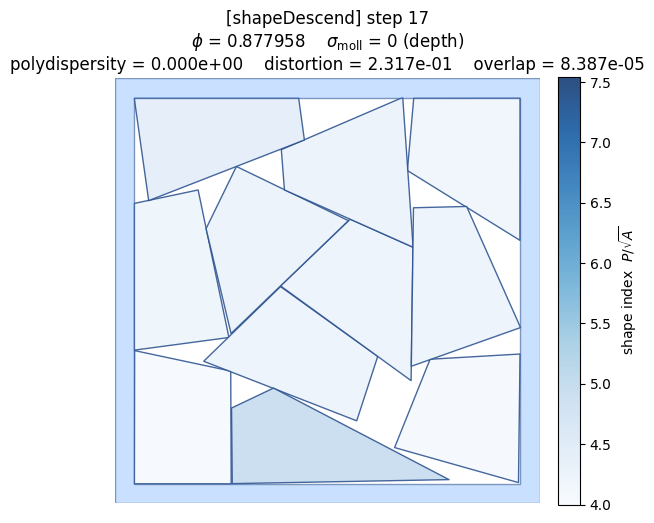

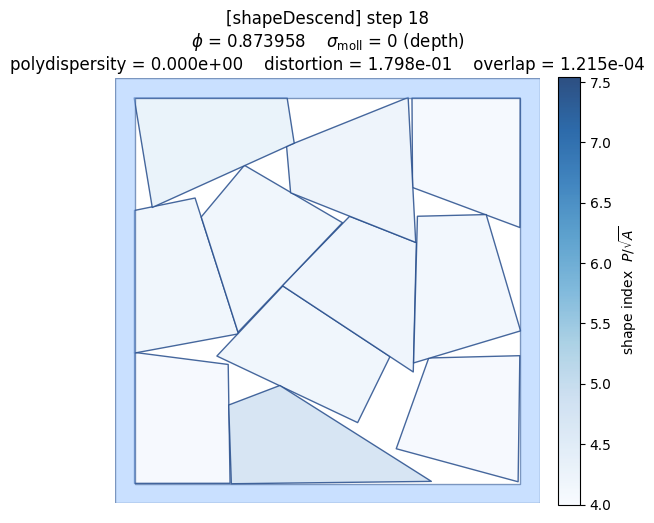

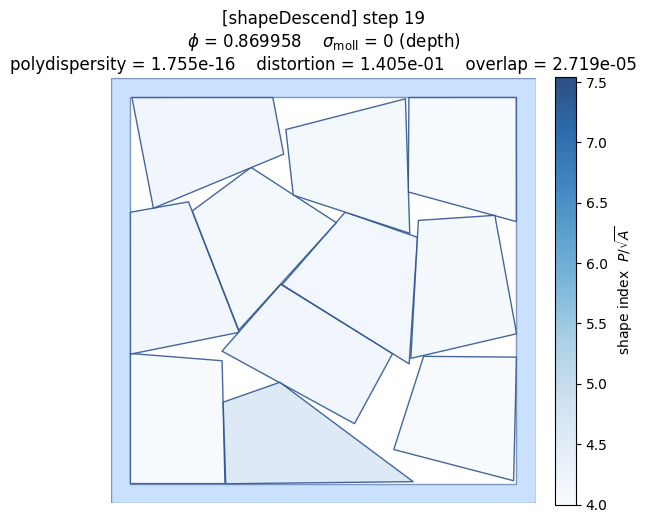

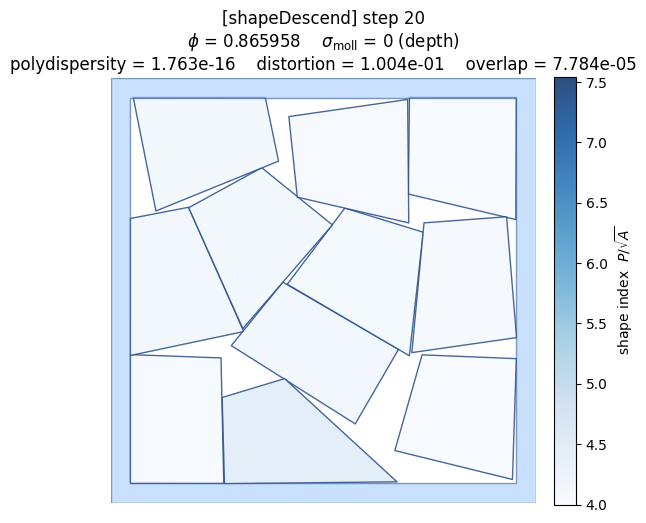

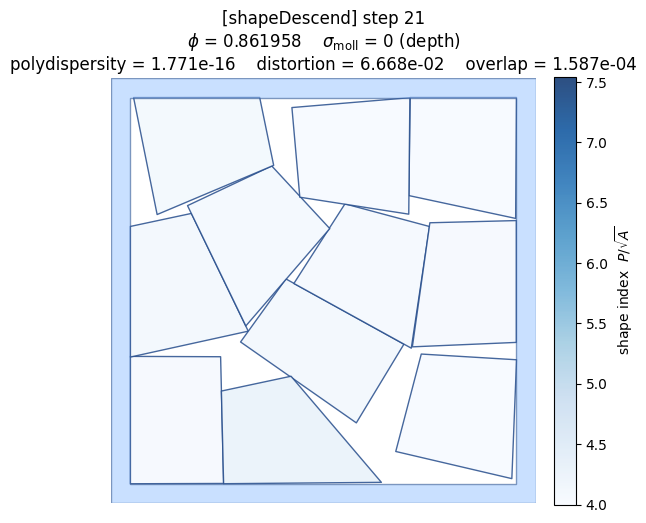

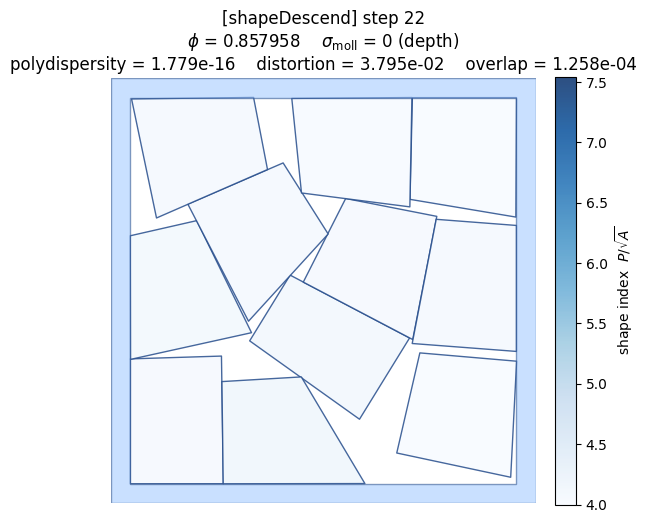

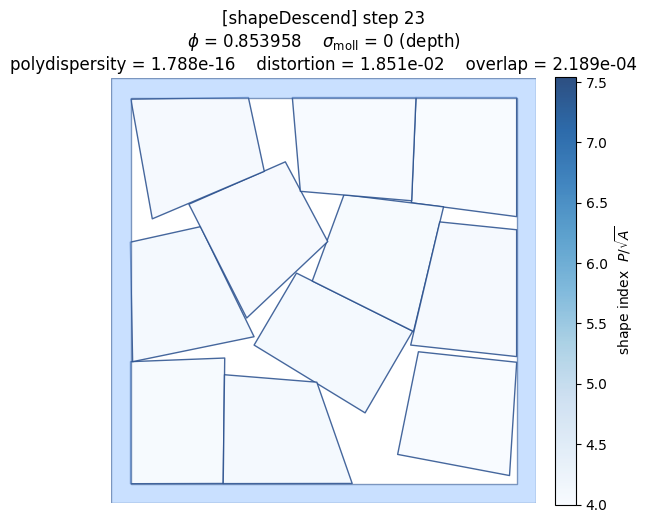

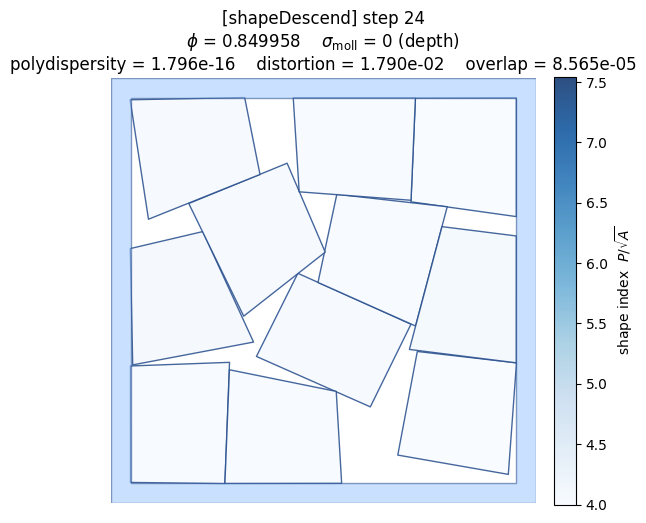

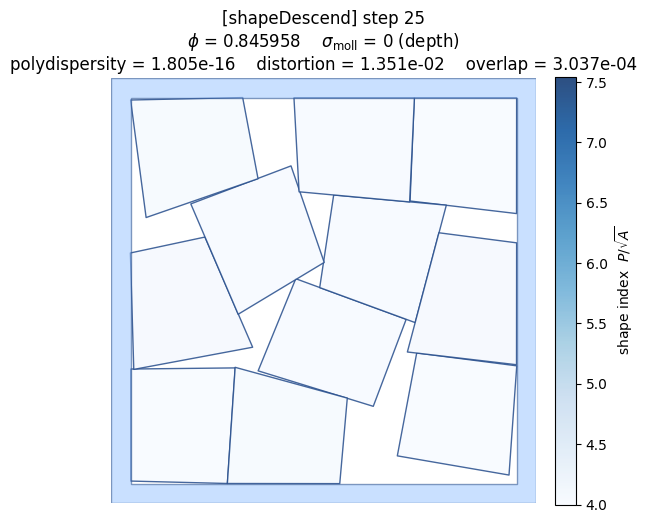

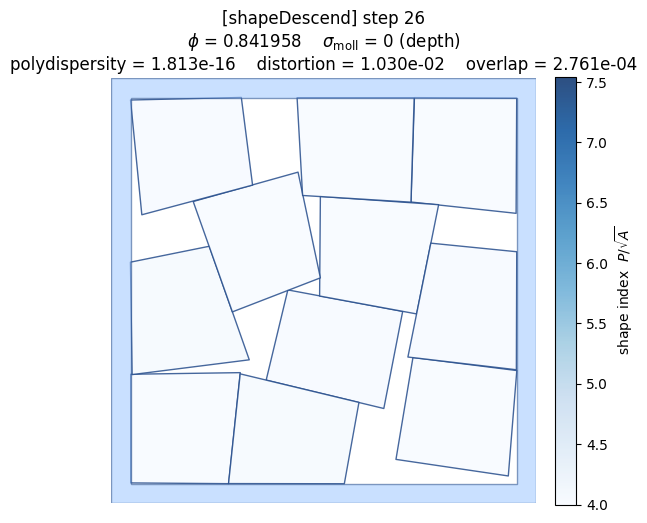

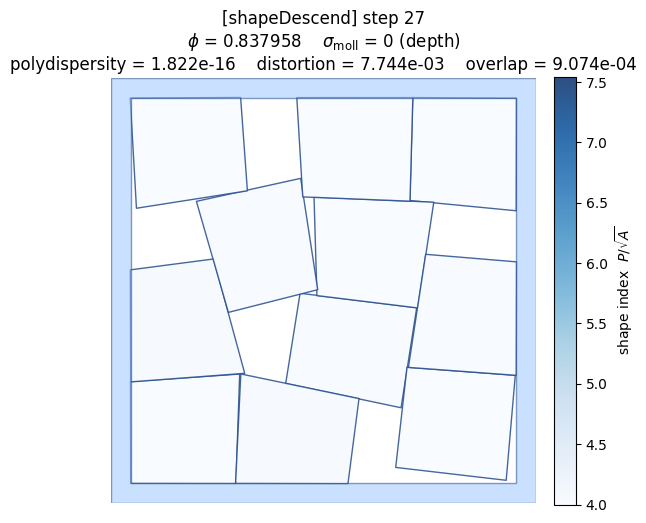

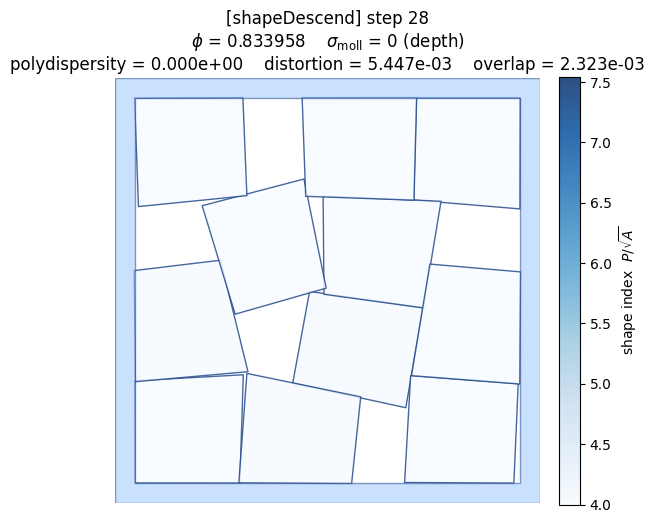

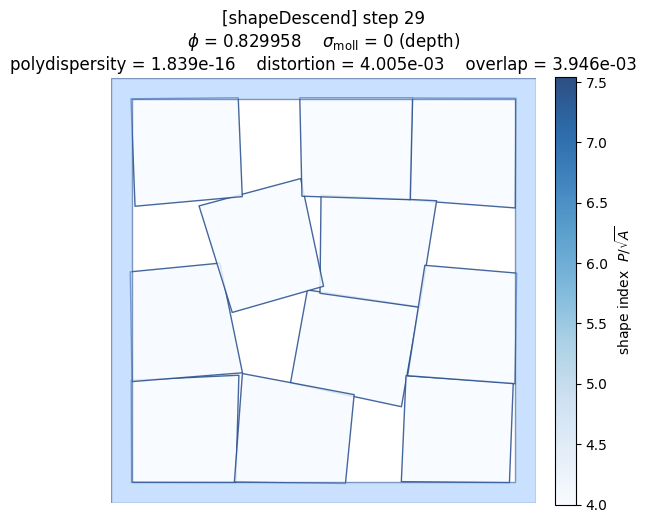

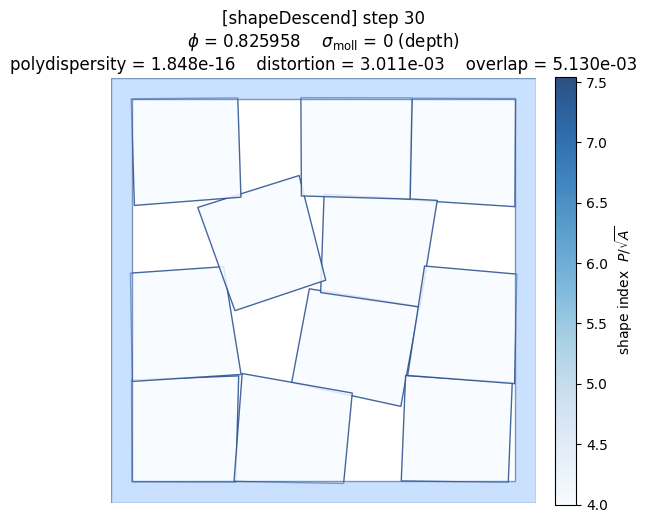

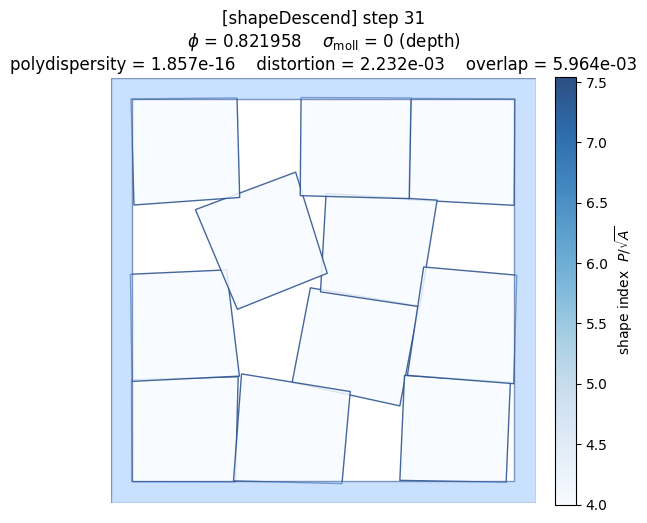

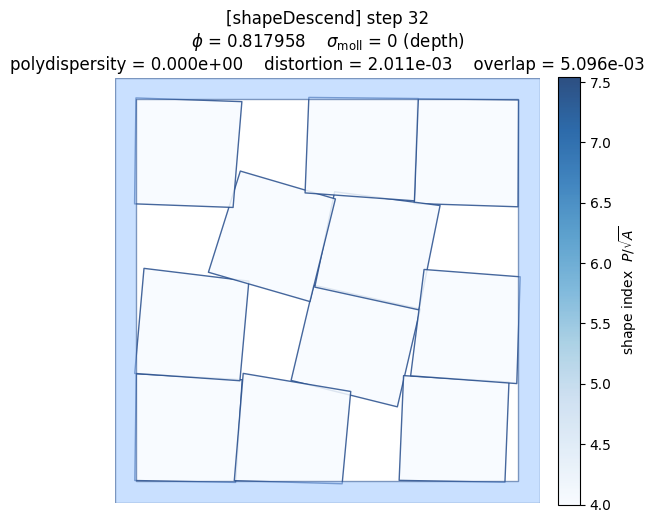

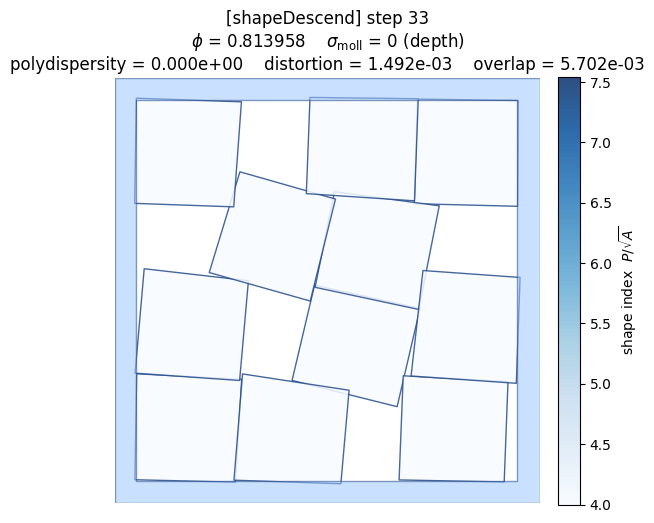

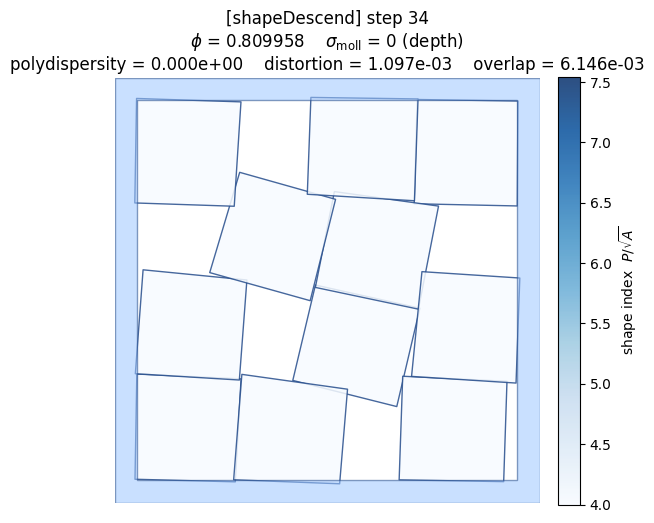

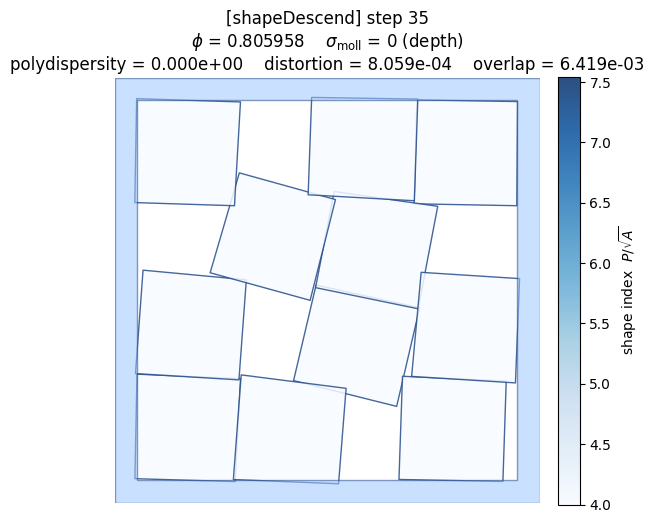

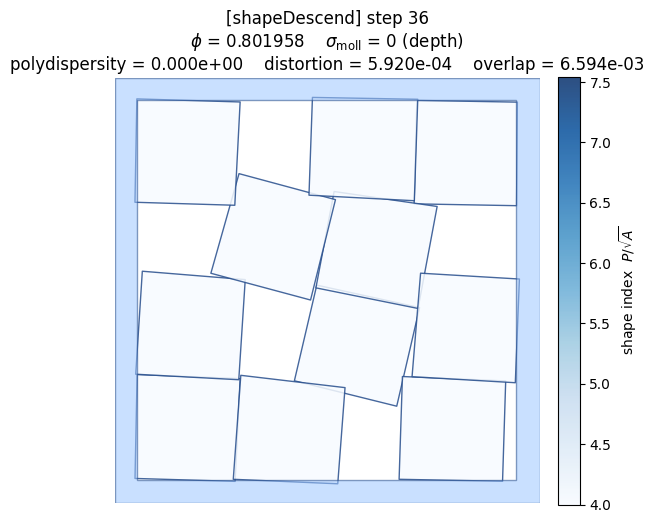

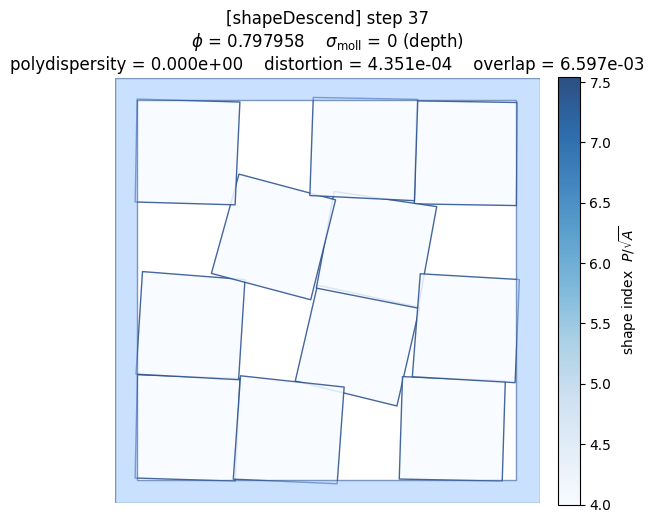

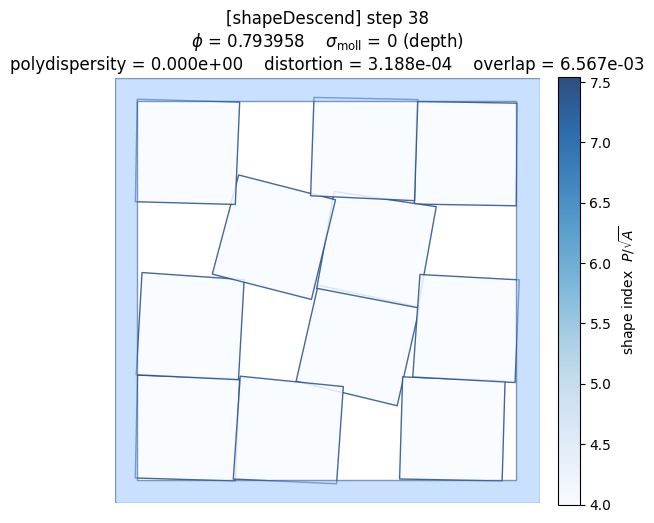

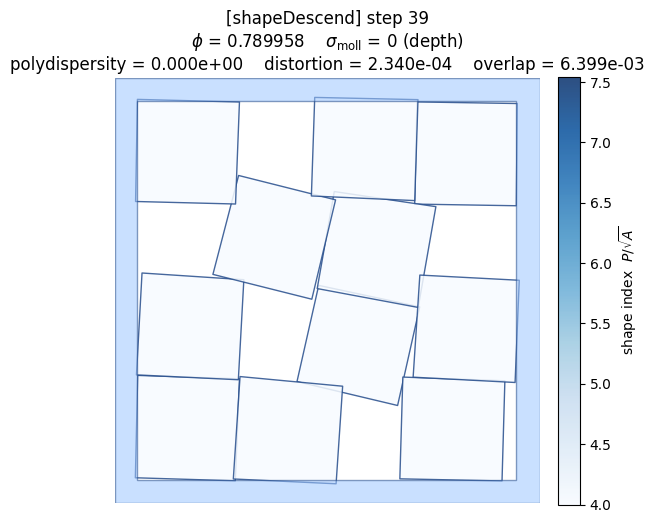

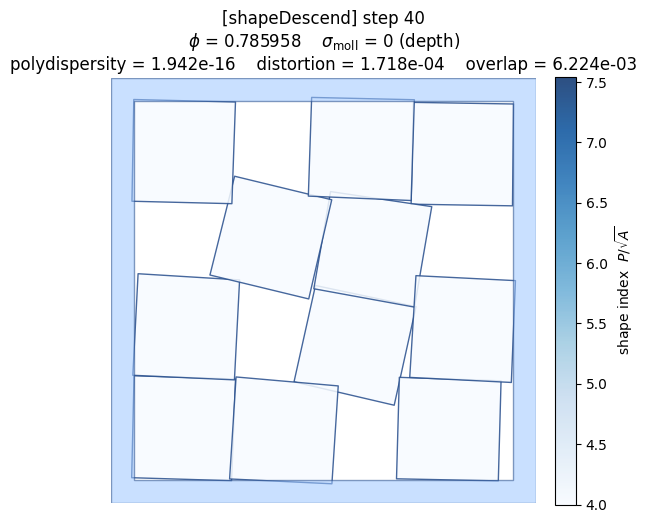

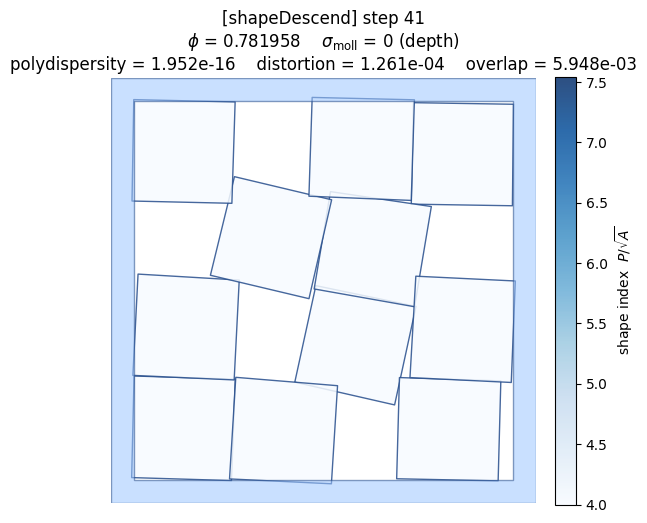

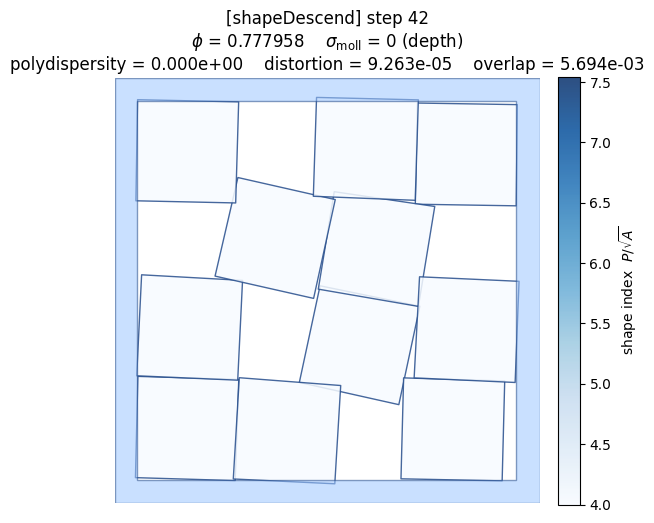

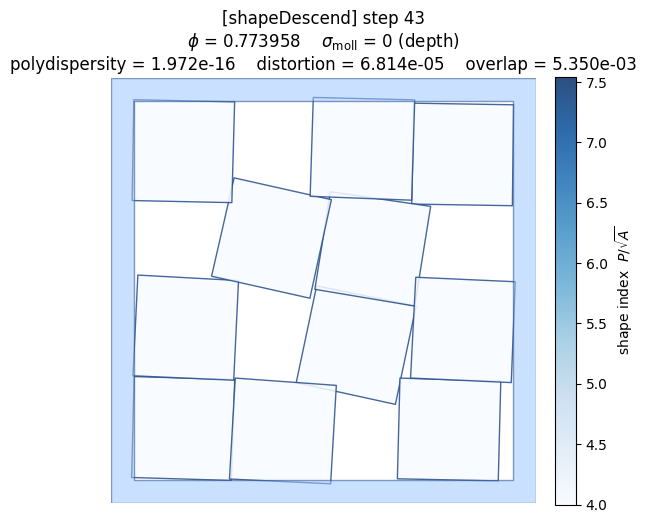

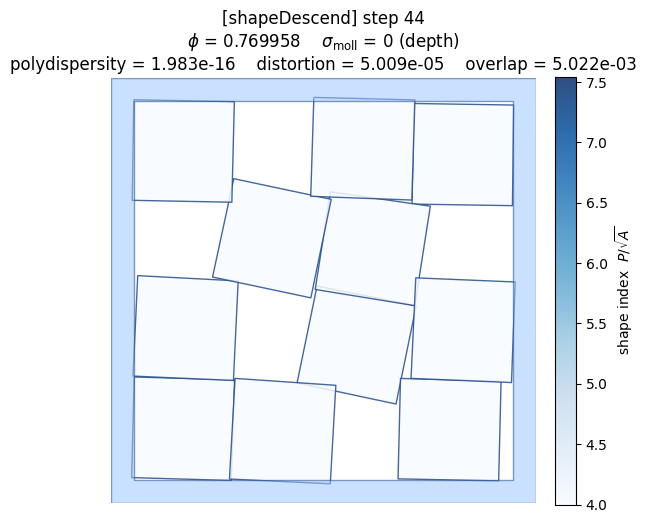

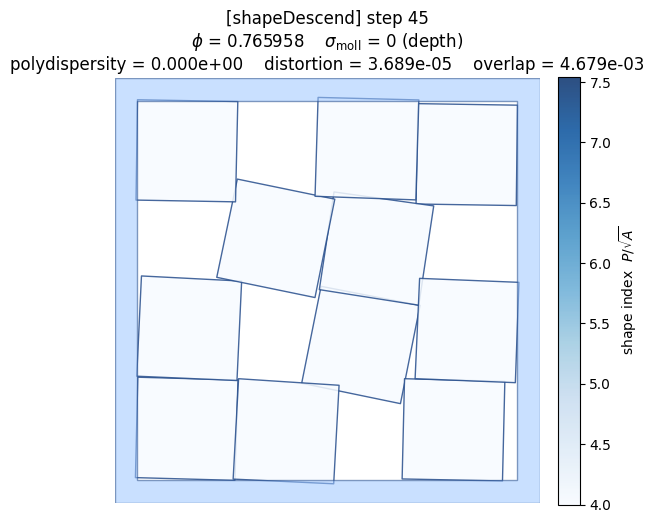

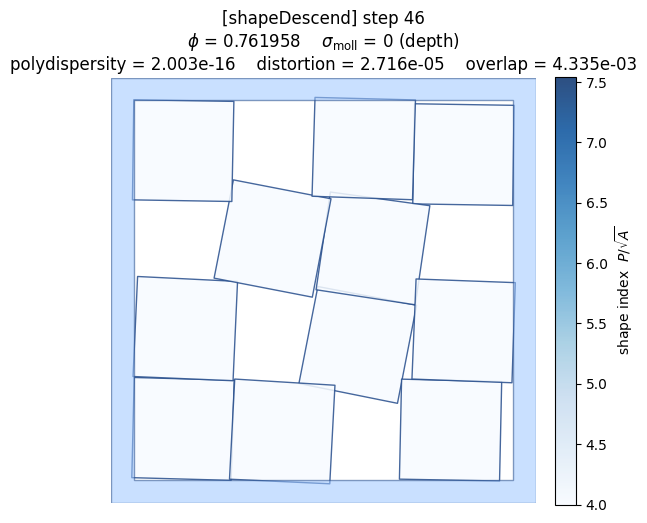

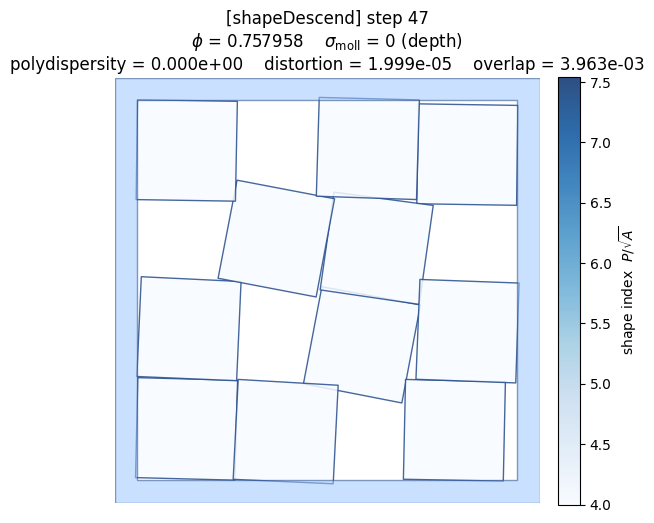

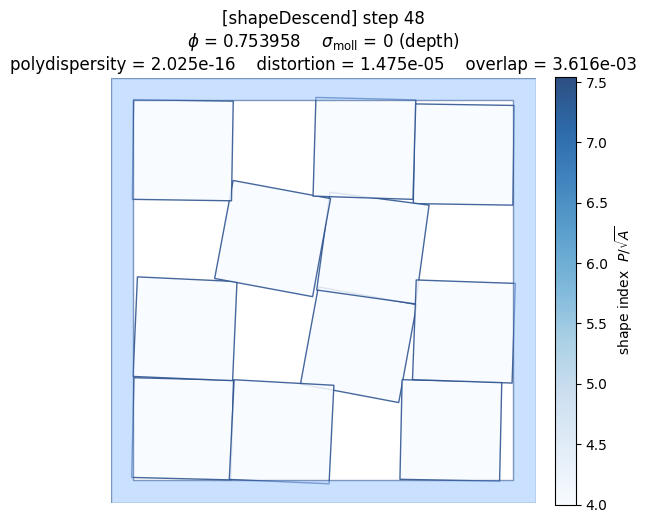

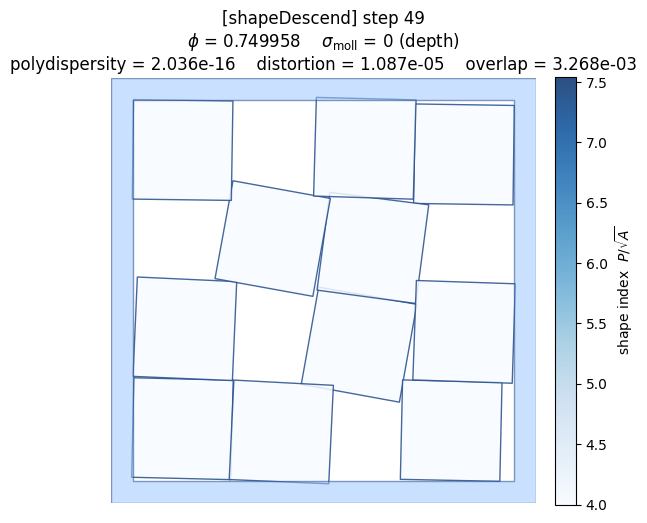

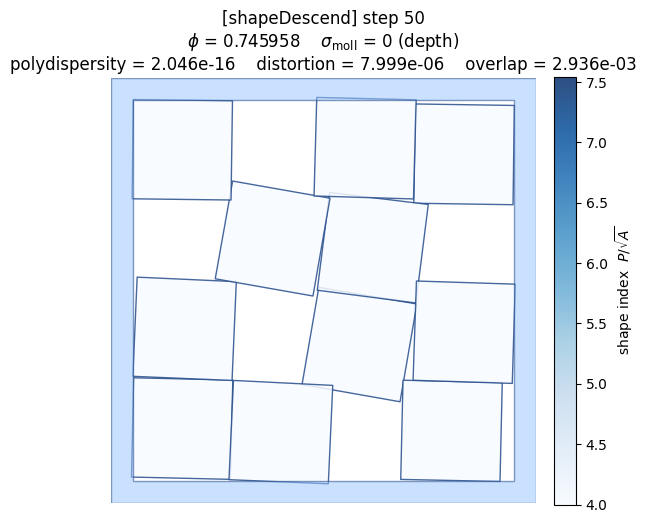

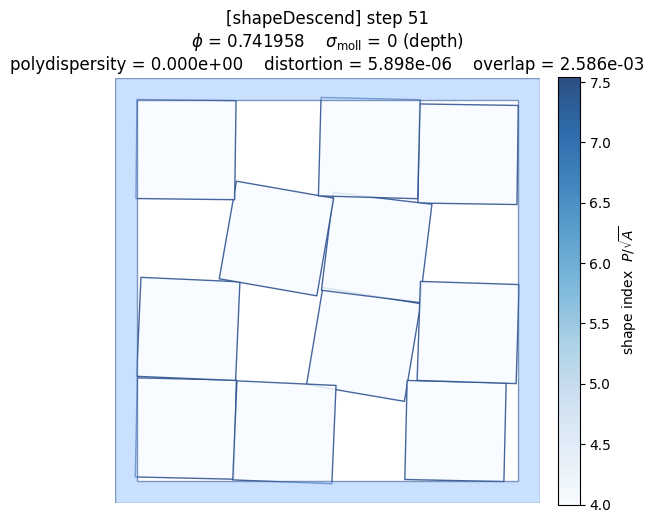

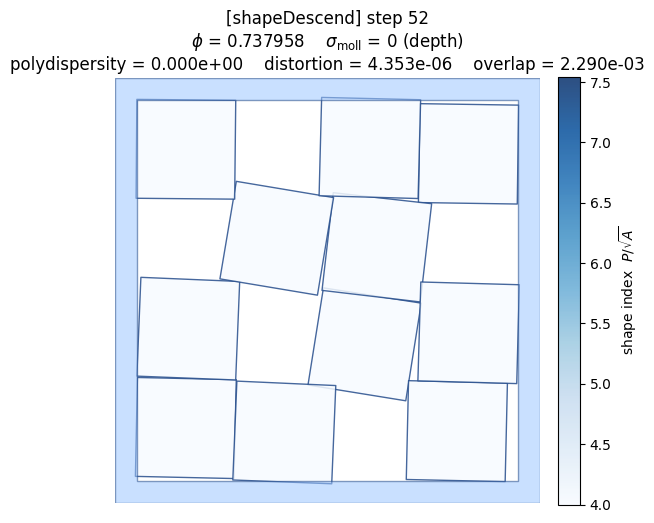

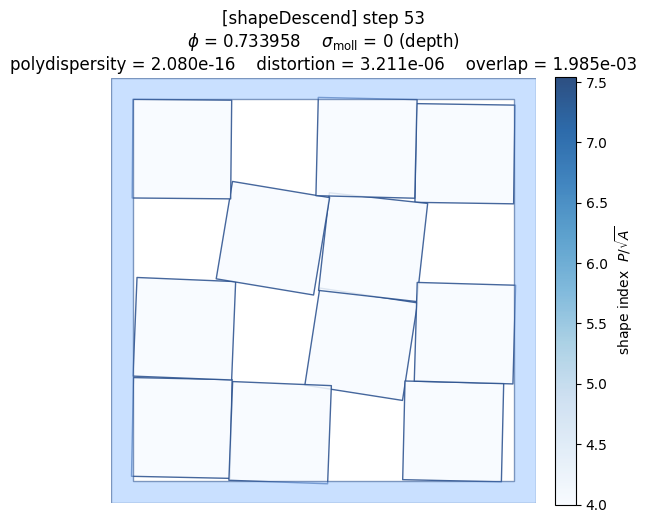

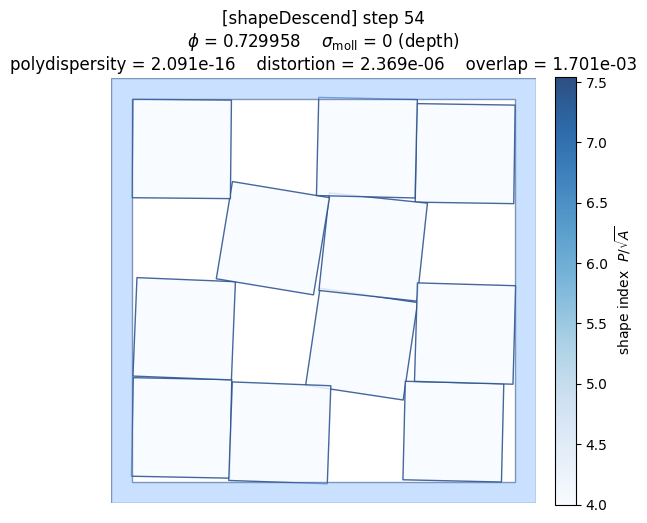

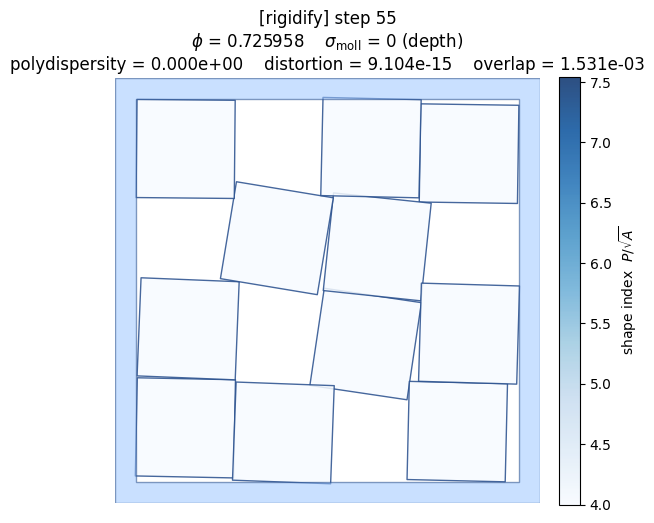

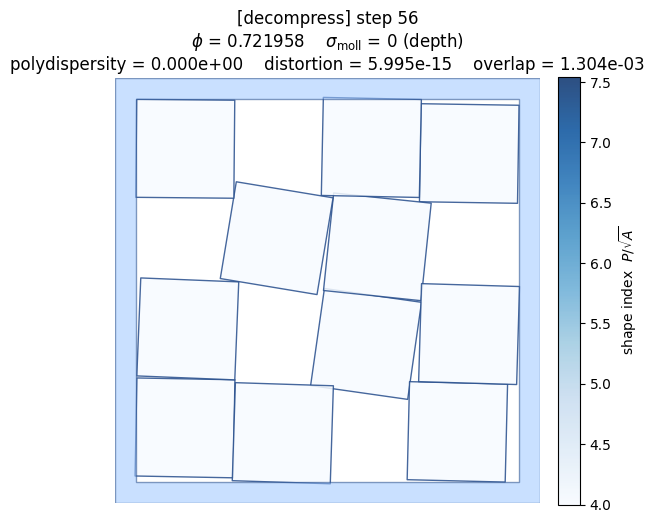

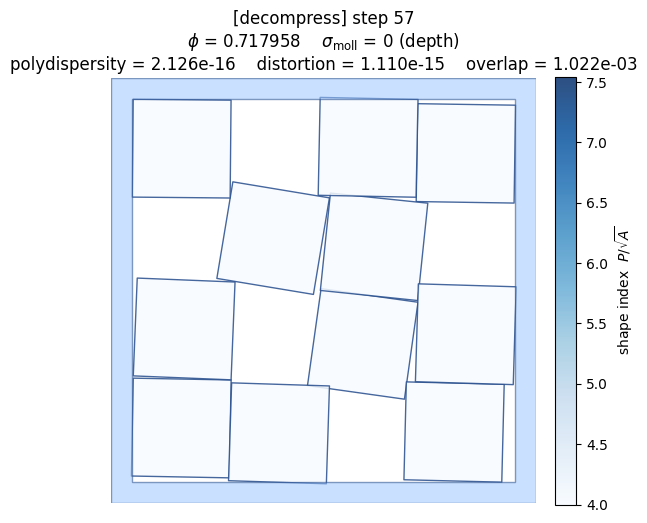

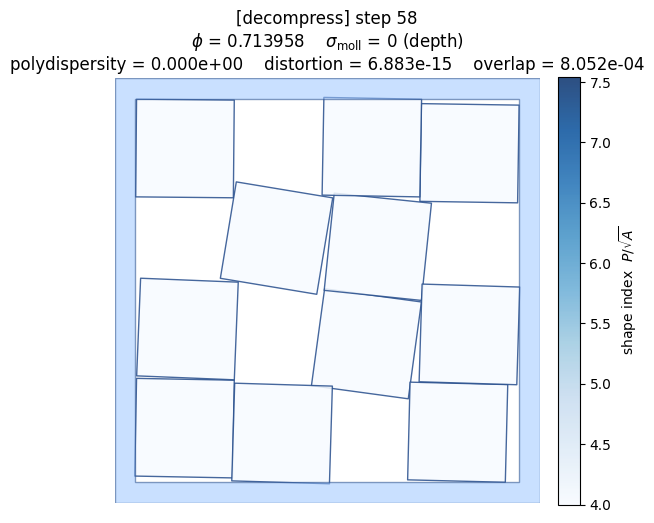

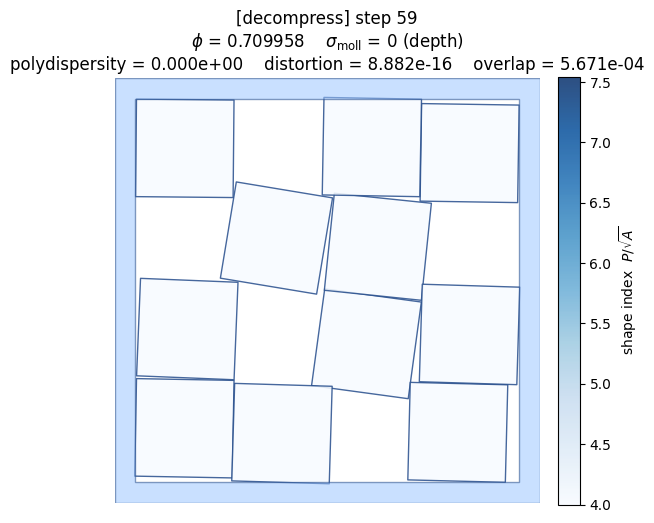

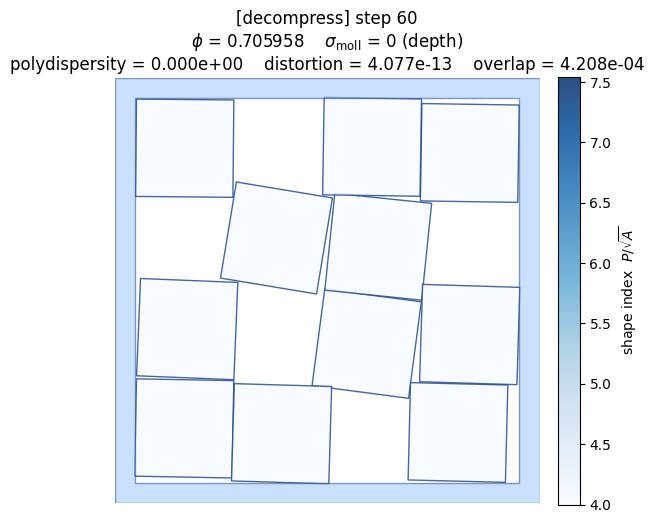

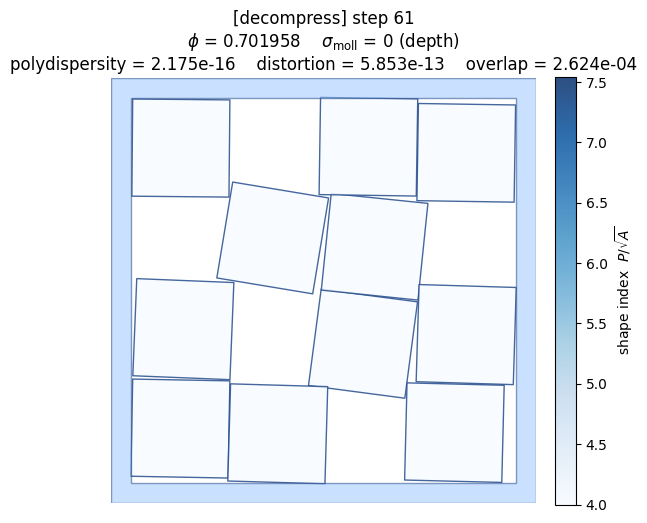

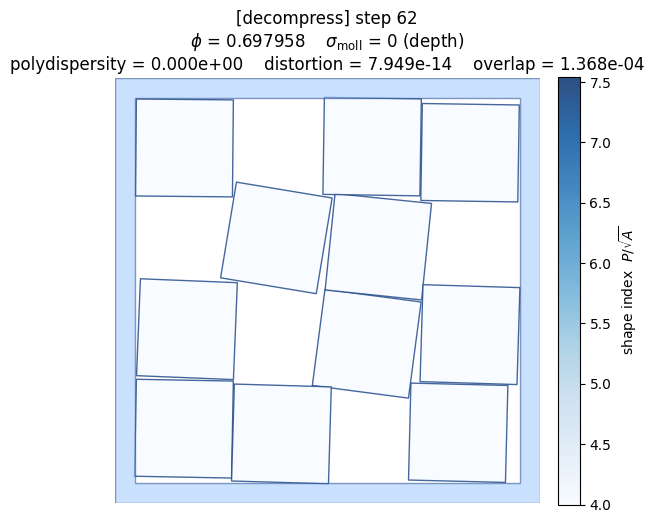

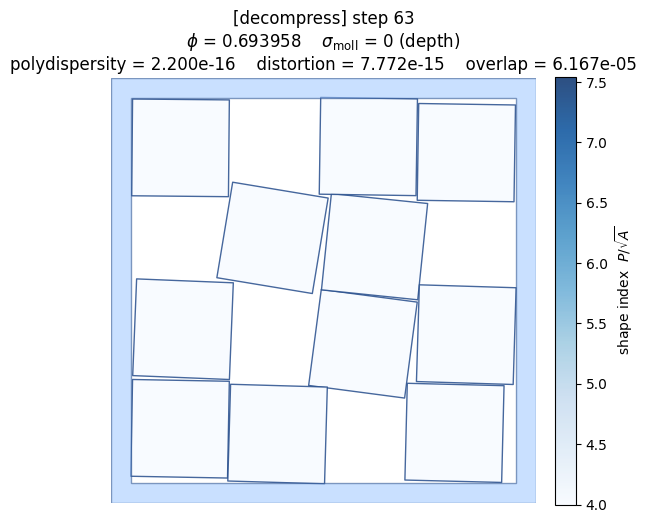

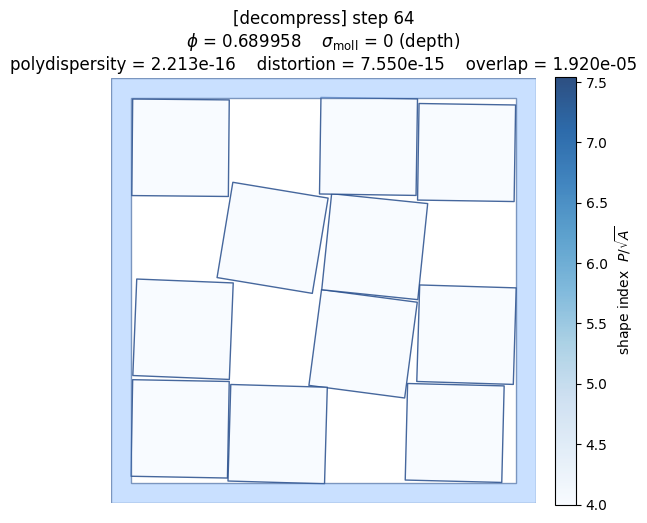

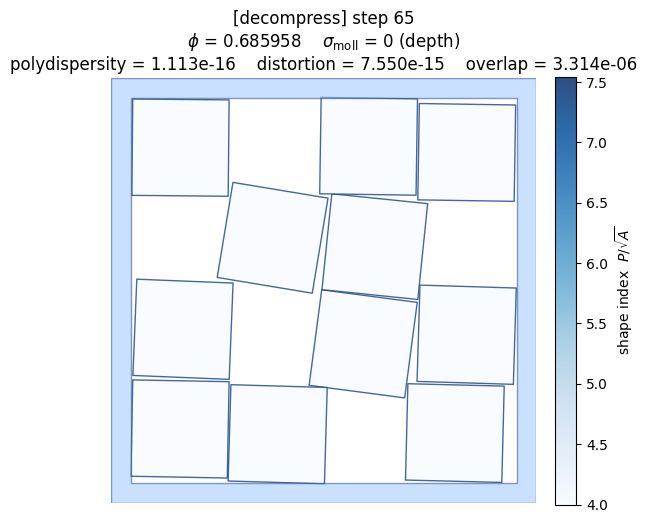

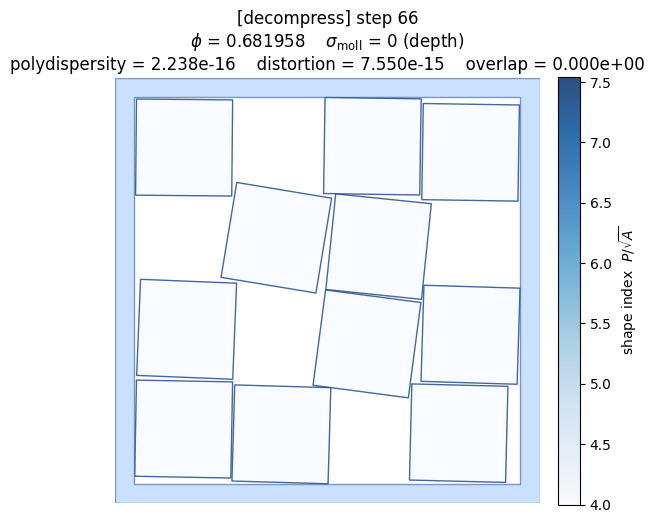

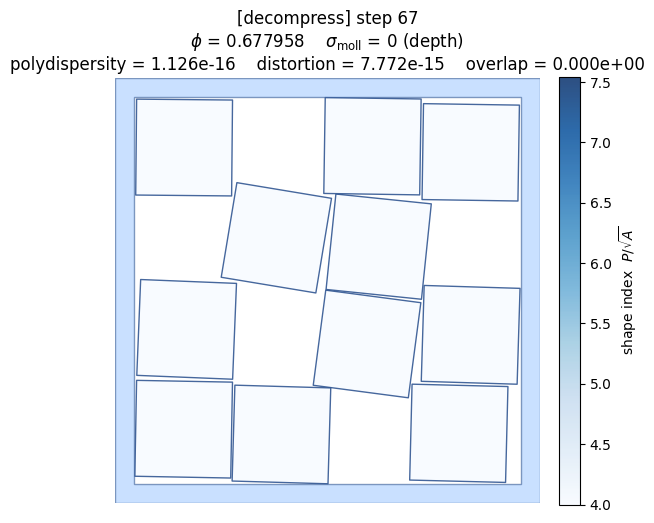

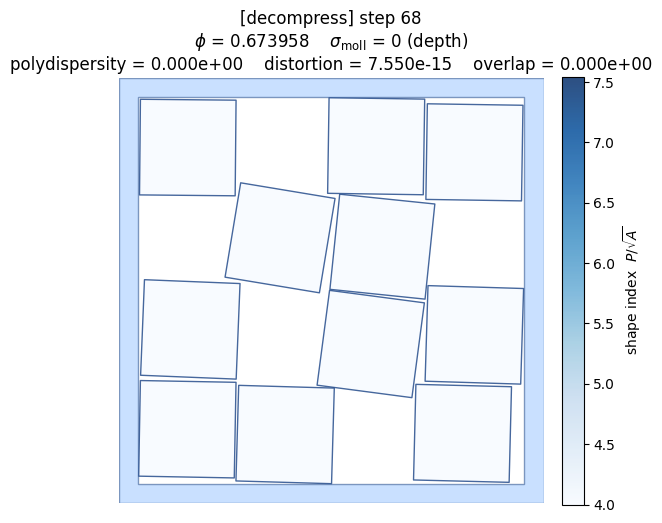

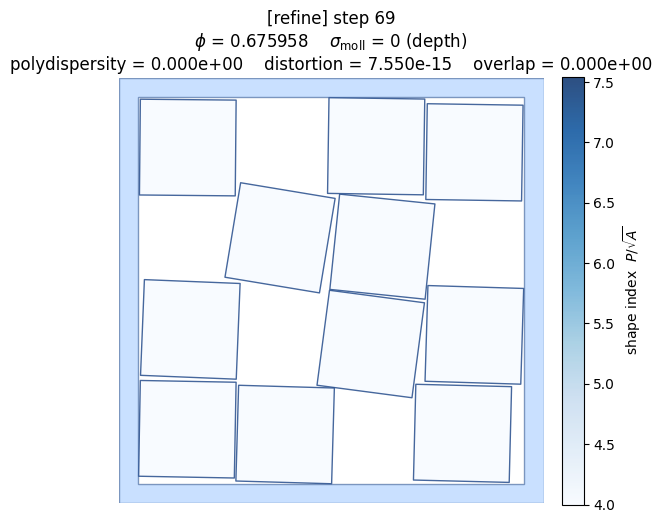

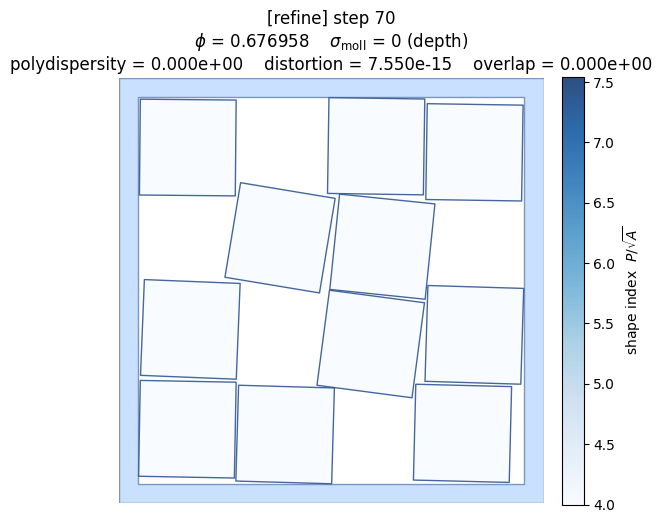

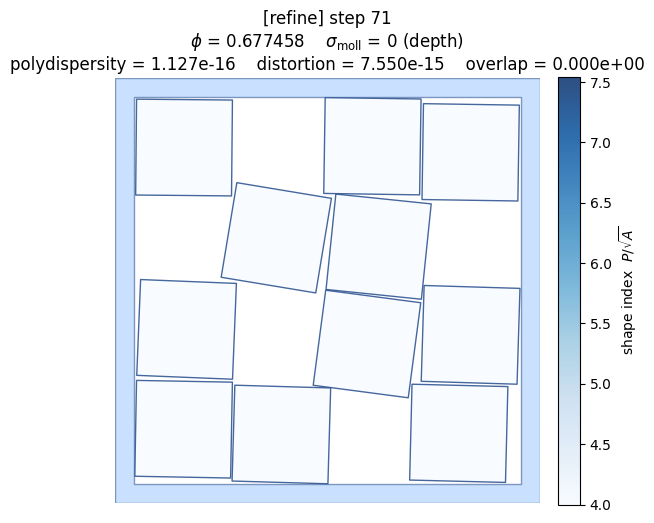

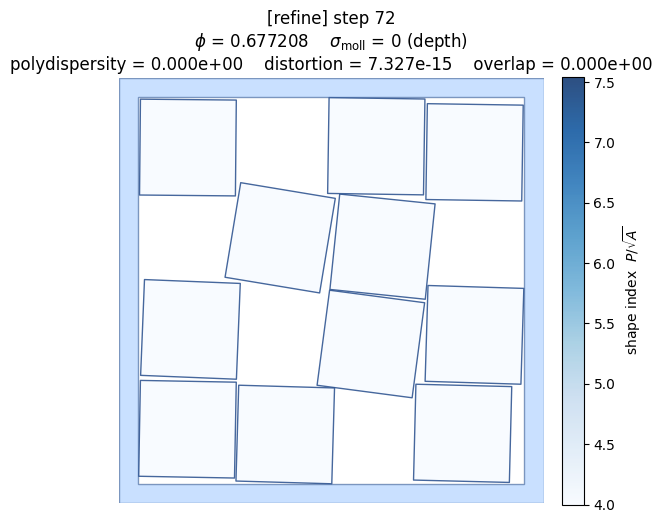

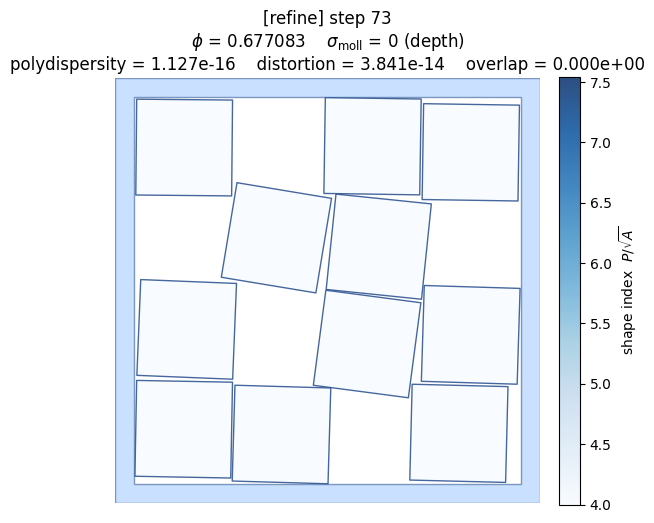

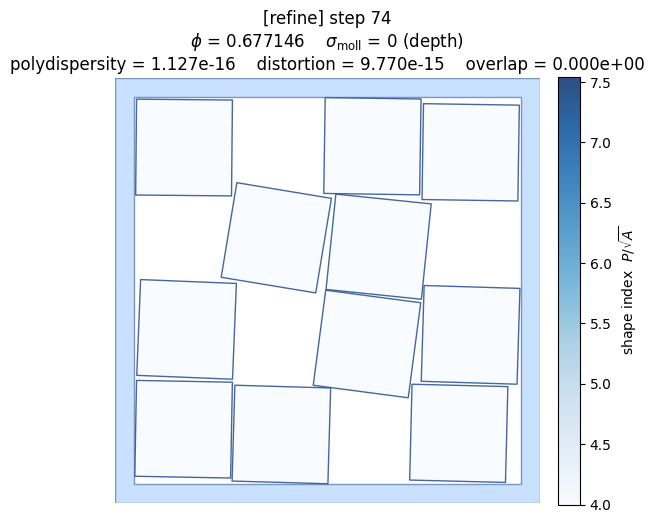

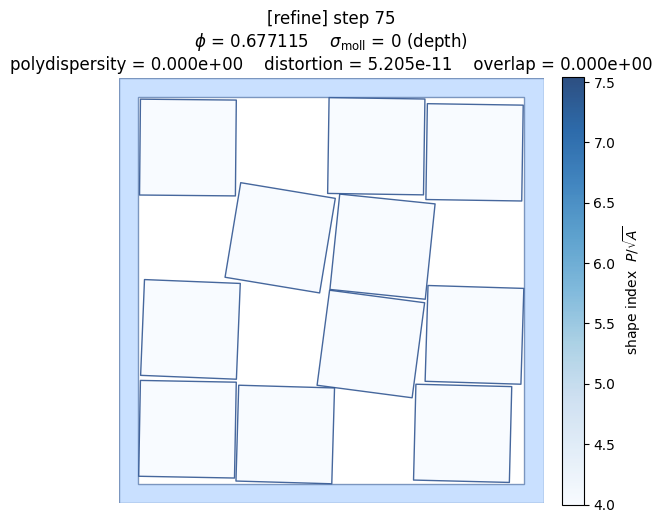

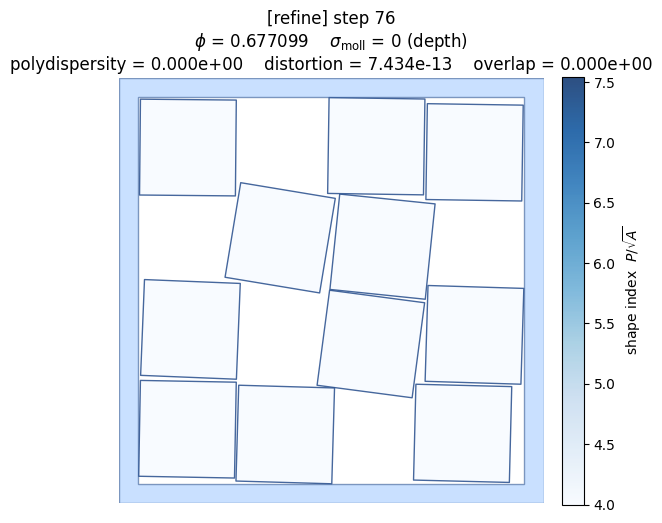

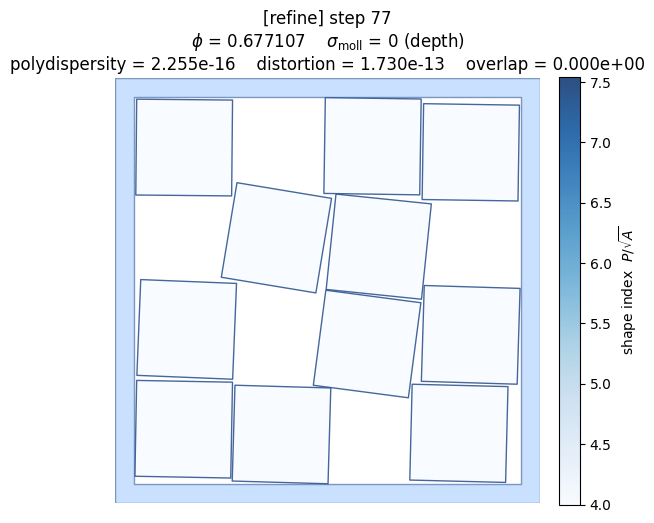

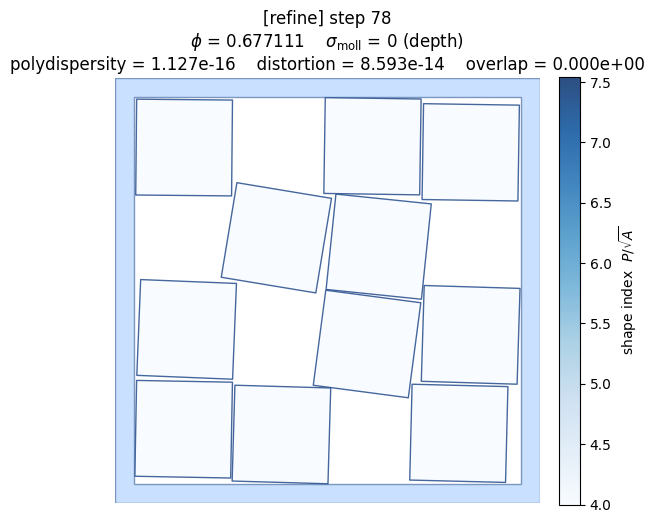

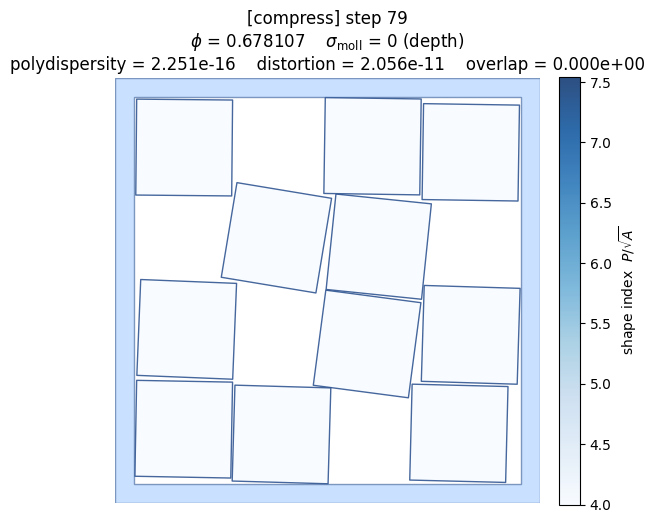

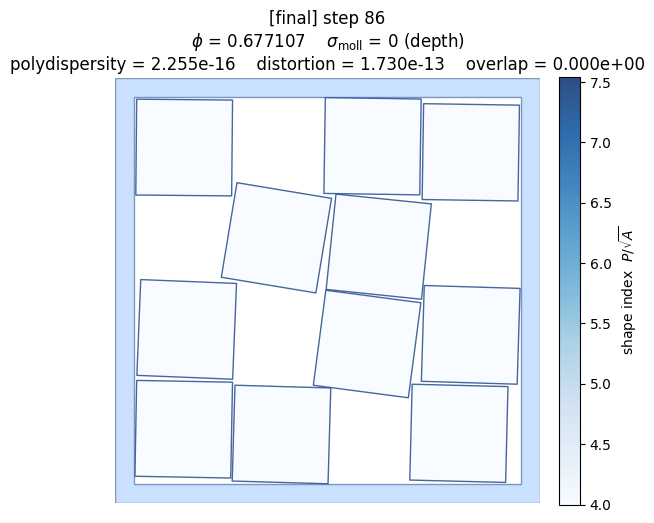

In [5]:
sol = packing.energySweep(minimizer = "lbfgs", shapeRounds = 42, progressBar = True, drawEvery = 1)

In [6]:
sol

<SweepResult phi = 0.677107, residual overlap 0.00e+00, 86 steps>

<Axes: >

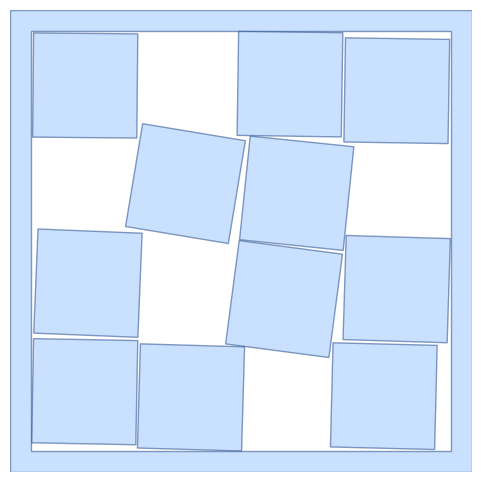

In [7]:
packing.draw()